# Notebook 2: Exploratory Data Analysis (EDA) 


The process conducted in this notebook involves the application of an Exploratory Data Analysis on the ‘candidates’ data migrated to the MySQL database.Basically, Exploratory Data Analysis (EDA) is the process of visually and statistically summarizing, exploring, and understanding the main characteristics, patterns, and relationships within a dataset.

### Importing libraries and modules


`sys.path.append()` allows importing modules from directories that are not in the default Python search path, which is necessary in this case to reuse a module created in the “source/connection/db_utils.py” directory of the project dedicated to the database utilities, like establishing and closing the connection to the database.

In [1]:
import os
import sys
import numpy as np 
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from fuzzywuzzy import process
import pycountry
sys.path.append(os.path.abspath('../src'))
from connection.db_utils import get_connection, close_connection

### Establishing the database connection

A SQLite engine object is created using the module `get_connection` located in the project´s `/src/connection/db_utils.py` script. Then, a connection object is created by connecting the engine.

In [2]:
engine = get_connection()

Engine created succesfully


### Reading the candidates data from the PosgreSQL database

This code first checks if an engine (a SQLAlchemy database connection object) is defined. If it exists, the code reads the "candidates_raw" table from the database into a Pandas DataFrame using `pd.read_sql_table`. Next, it verifies if the column "Application Date" is present in the DataFrame. If so, it converts the values in that column to a datetime format using the `pd.to_datetime` function with the `dayfirst=True` parameter, which ensures that the day is interpreted before the month (e.g., 31/12/2020 rather than 12/31/2020). This prepares the data for consistent and accurate datetime manipulation.

Following the data retrieval, the `df.head(3)` method is invoked. This command displays the first three rows of the DataFrame, providing a concise preview of the data. This allows for immediate verification that the data was successfully extracted from the SQL table and offers a quick look at the structure and initial records of the dataset, facilitating a basic understanding of the data's format and content.

In [3]:
if engine:
    df = pd.read_sql_table("candidates_raw", engine)

    if 'Application Date' in df.columns:
        df['Application Date'] = pd.to_datetime(df['Application Date'], dayfirst=True)

df.head(3)

,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9


In [4]:
close_connection(engine)

Engine connection closed.


### Data profiling

Data profiling is an invaluable step in the data preparation process. While it doesn’t fully automate data type mapping, it provides crucial insights needed to make informed decisions and create a well-designed database schema in the future.

#### Shape of the data

We get the shape of the data using Pandas `.shape` method.

In [5]:
df.shape

(50000, 10)

This means that this dataset has 50000 rows and 10 columns.

#### Data types

We inspect the columns and their data types using the Pandas `.info()` method.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   First Name                 50000 non-null  object        
 1   Last Name                  50000 non-null  object        
 2   Email                      50000 non-null  object        
 3   Application Date           50000 non-null  datetime64[ns]
 4   Country                    50000 non-null  object        
 5   YOE                        50000 non-null  int64         
 6   Seniority                  50000 non-null  object        
 7   Technology                 50000 non-null  object        
 8   Code Challenge Score       50000 non-null  int64         
 9   Technical Interview Score  50000 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 3.8+ MB


We can see that the DataFrame contains 3 columns with the "int64" data type 6 columns with the "object" data type, and o1 column with the "datetime64" data type. This data types are optimal for our analysis.

#### Data cardinality

The "cardinality" of a column is the number of unique values in it. High cardinality means many unique values, while low cardinality means few.

Pandas `.nunique()` method helps us to identify the number of distinct categories in a column, which is essential for analyzing categorical variables.


In [7]:
df.nunique()

First Name                    3007
Last Name                      474
Email                        49833
Application Date              1646
Country                        244
YOE                             31
Seniority                        7
Technology                      24
Code Challenge Score            11
Technical Interview Score       11
dtype: int64

* **"First Name 3007":** This means there are 3,007 distinct first names in the "First Name" column.
* **"Last Name 474":** There are 474 unique last names. This indicates less diversity compared to first names, potentially suggesting some last names are repeated more frequently.
* **"Email 49833":** This shows 49,833 unique email addresses. Given that the data has 50,000 rows, this suggests that almost every row has a unique email, which is expected, but emails should be unique for each candidate, so this also sugests a duplication problem.
* **"Application Date 1646":** There are 1,646 unique application dates. This indicates that applications were submitted on a variety of different days.
* **"Country 244":** There are 244 distinct countries represented in the dataset. This is suspicious there are 195  recognized countries in the world.
* **"YOE 31":** "YOE" likely stands for "Years of Experience." There are 31 unique values, meaning applicants have a range of experience levels.
* **"Seniority 7":** There are 7 unique seniority levels. This suggests a relatively small number of defined seniority categories.
* **"Technology 24":** There are 24 unique technologies listed. This indicates a variety of technical skills among the applicants.
* **"Code Challenge Score 11":** There are 11 unique scores for the code challenge. This likely means the scores are discrete or binned into a limited number of categories.
* **"Technical Interview Score 11":** Similar to the code challenge score, there are 11 unique technical interview scores.

#### Describe

We get quick summary of the dataset using the Pandas `describe()` method. The `describe()` function applies basic statistical computations on the dataset like extreme values, count of data points standard deviation, etc. Any missing value or NaN value is automatically skipped. `describe()` function gives a good picture of the distribution of data.

Note we can also get the description of categorical columns of the dataset if we specify `include ='all'`  in the describe function.




In [8]:
df.describe(include='all') 

,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
count,50000,50000,50000,50000,50000,50000.000000,50000,50000,50000.000000,50000.000000
unique,3007,474,49833,NaN,244,NaN,7,24,NaN,NaN
top,Sarai,Murazik,marianne31@yahoo.com,NaN,Malawi,NaN,Intern,Game Development,NaN,NaN
freq,33,138,3,NaN,242,NaN,7255,3818,NaN,NaN
mean,NaN,NaN,NaN,2020-04-03 23:04:14.592000,NaN,15.286980,NaN,NaN,4.996400,5.003880
min,NaN,NaN,NaN,2018-01-01 00:00:00,NaN,0.000000,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,2019-02-17 00:00:00,NaN,8.000000,NaN,NaN,2.000000,2.000000
50%,NaN,NaN,NaN,2020-04-06 00:00:00,NaN,15.000000,NaN,NaN,5.000000,5.000000
75%,NaN,NaN,NaN,2021-05-21 00:00:00,NaN,23.000000,NaN,NaN,8.000000,8.000000
max,NaN,NaN,NaN,2022-07-04 00:00:00,NaN,30.000000,NaN,NaN,10.000000,10.000000


The Email column's high uniqueness suggests strong identifiers for individuals, while duplicate First Name or Last Name occurrences are expected since these aren't unique identifiers.

Technology and Seniority values are skewed toward a few popular categories like "Game Development" and "Intern." Seniority contains 7 unique values, and "Intern" is the most frequent with 7,255 entries. Technology has 24 unique values, and "Game Development" is the most common at 3,818 occurrences.

The earliest date is January 1, 2018, while the latest is July 4, 2022. This shows the data spans over almost but not quite 4 years, so there is data missing from 2022.

In both scores (technical interview and code challenge), their means (~5), medians (5), and standard deviations (~3) indicate these scores are symmetrically distributed.

Country has 244 unique values, with "Malawi" being the most common, appearing 242 times. This is interesting given Malawi is a country in development, with most of its economy geared toward the primary sector, and not the quaternary.


### Handling Missing Values

Missing Data can also refer to as NA(Not Available) values in pandas. There are several useful functions for detecting, removing, and replacing null values in Pandas DataFrame. To detect missing values in the DataFrame `df.isnull().sum()` is used.


In [9]:
df.isnull().sum()

First Name                   0
Last Name                    0
Email                        0
Application Date             0
Country                      0
YOE                          0
Seniority                    0
Technology                   0
Code Challenge Score         0
Technical Interview Score    0
dtype: int64

The output confirms that there is no null data in the dataset.

### Exploring data characteristics (before transformations)

By exploring the characteristics of the data very well, one can gain treasured insights into its structure, pick out capability problems or anomalies, and inform the subsequent evaluation and modeling choices. Documenting any findings or observations from this step is critical, as they may be relevant for destiny reference or communication with stakeholders.

#### Geographical distribution

##### Top countries with the highest applicant counts (bar chart)

Seaborn's barplot is used to visualize the top 20 countries with the highest applicant counts.

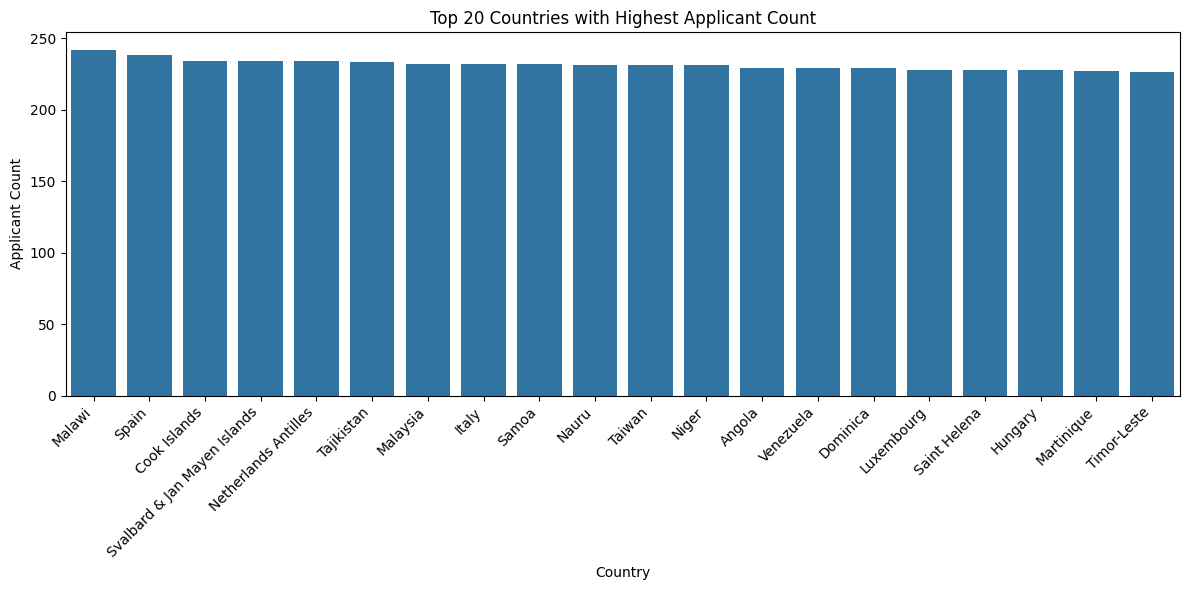

In [10]:
country_counts = df['Country'].value_counts().head(20)  
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Countries with Highest Applicant Count')
plt.xlabel('Country')
plt.ylabel('Applicant Count')
plt.tight_layout()
plt.show()

* Even Distribution: The graph indicates that each of the 20 countries or territories has nearly the same number of applicants (around 250). This might suggest that the program is intentionally maintaining a balance across regions or that there’s a widespread global interest in the opportunity.

* Global Representation: There’s a mix of regions represented—countries from Europe, Asia, Africa, the Americas, and even small island territories. This diversity could imply that the program is successful in attracting applicants from various parts of the world, fostering inclusivity.

* Notable Territories: The inclusion of places like Svalbard & Jan Mayen Islands and Netherlands Antilles is intriguing, as these are smaller or less common territories in global applicant lists. It could mean the program has some unique outreach efforts or appeal in these regions.

##### Relation Between Country and Technology (Grouped Bar Chart)

Filters the DataFrame to include only the top 20 countries and top 5 technologies for clarity.
Uses groupby and unstack to create a pivot table for the grouped bar chart.
Visualizes the relationship between countries and technologies.

<Figure size 2000x1000 with 0 Axes>

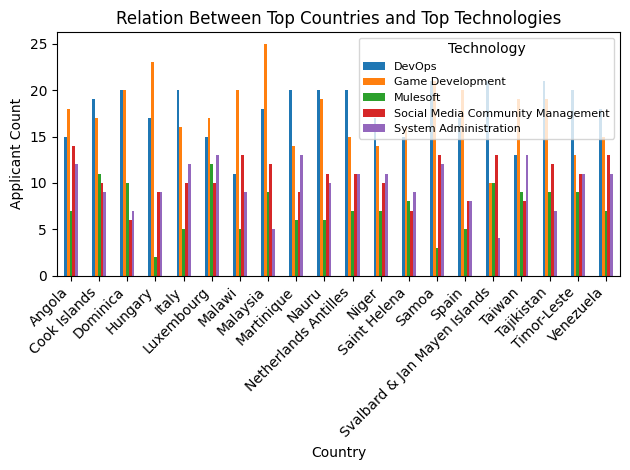

In [11]:
top_countries = df['Country'].value_counts().head(20).index  # Top 20 countries
top_technologies = df['Technology'].value_counts().head(5).index  # Top 5 technologies

filtered_df = df[df['Country'].isin(top_countries) & df['Technology'].isin(top_technologies)]
grouped_data = filtered_df.groupby(['Country', 'Technology']).size().unstack(fill_value=0)


plt.figure(figsize=(20, 10))  
grouped_data.plot(kind='bar', stacked=False)
plt.title('Relation Between Top Countries and Top Technologies')
plt.xlabel('Country')
plt.ylabel('Applicant Count')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Technology', fontsize=8, title_fontsize=10, loc='best')  

plt.tight_layout()
plt.show()



- Applicant distribution across countries shows significant variation. For example, Malaysia exhibits a peak in interest for Game Development. This could signal a regional specialization or a strong industry presence there.

- Smaller territories like Cook Islands and Saint Helena show consistently lower counts across all technologies, possibly due to their smaller populations. These territories contribute marginally to the total applicant pool, which could indicate limited accessibility or awareness of the technologies.

- Certain countries show a dominant preference for specific technologies. For instance, Malaysia has a clear affinity for Game Development, with a skewed distribution toward this technology. Spain, meanwhile, shows a more balanced representation but a slight preference for DevOps.

- On the contrary, Taiwan exhibits relatively equal distribution across technologies, indicating diversified tech interests within its applicant pool.

- Across all countries, Game Development and DevOps emerge as the most popular technologies, collectively capturing over 60% of the total applicant counts. This dominance suggests that these fields are globally trending or have more lucrative career opportunities.

- Technologies like Mulesoft and Social Media Community Management have significantly lower counts. These could represent niche interests or fields that are either less familiar or have fewer job opportunities globally.

- Malaysia is an outlier in the dataset for Game Development, with counts disproportionately higher than other countries. This may warrant further investigation into the factors driving this trend, such as local industry growth, educational initiatives, or cultural preferences.

- Larger countries (e.g., Spain, Malaysia) generally have higher applicant counts, aligning with population size and tech ecosystem maturity. However, the inclusion of small territories like Luxembourg or Saint Helena suggests the possibility of targeted campaigns or a high level of engagement within smaller populations.

- Countries like Luxembourg and Taiwan show a more even distribution across technologies, while others are more skewed (e.g., Malaysia with Game Development). This could indicate either cultural or educational biases in certain regions or program strategies focusing on specific technologies.

#####  Correlation Between Country and Seniority (Heatmap)

This heatmap titled "Correlation Between Top Countries and Seniority Levels" allows us to analyze the strength of relationships between the listed countries and their respective seniority levels. 

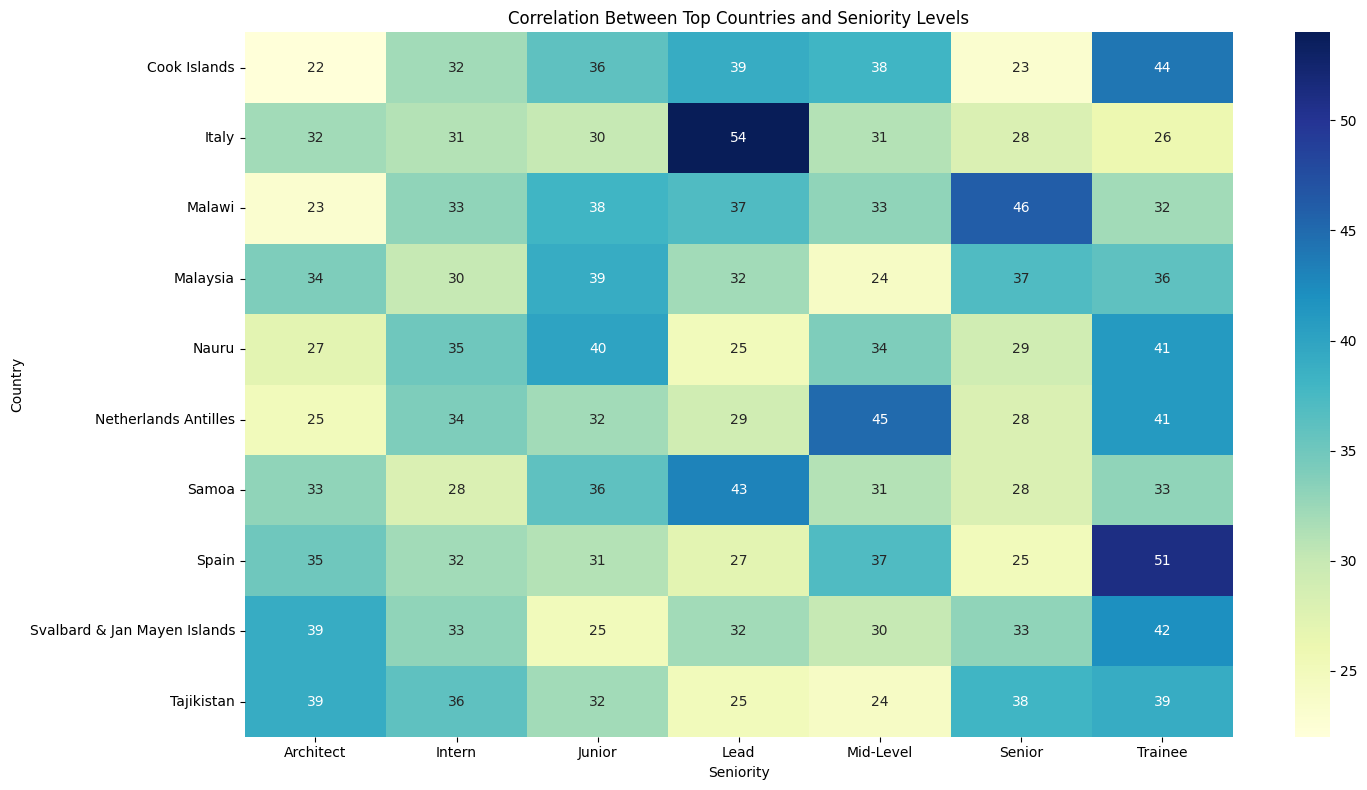

In [12]:
top_countries = df['Country'].value_counts().head(10).index
seniority_levels = df['Seniority'].unique()

filtered_df = df[df['Country'].isin(top_countries)]
grouped_data = filtered_df.groupby(['Country', 'Seniority']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
sns.heatmap(grouped_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation Between Top Countries and Seniority Levels')
plt.xlabel('Seniority')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### Analysis by Country

**Malaysia:**

- Shows strong correlations with senior roles like Architect and Senior levels.
- This trend could indicate a tech-savvy or advanced employment market, where experienced professionals are in demand or well-represented.

**Spain:**

- Demonstrates relatively high correlations with Mid-Level positions. This may suggest a workforce with a significant proportion of professionals at the intermediate career stage.

**Svalbard & Jan Mayen Islands:**

- Displays low correlations across all seniority levels. This could be due to smaller applicant pools or less industry-specific representation from these regions.

**Netherlands Antilles and Cook Islands:**

- Tend to skew toward trainee or junior positions, which might suggest a developing employment market or an emphasis on early-career opportunities in these territories.

##### Analysis by Seniority

**Architect and Senior Levels:**

- These are more correlated with countries like Malaysia and Spain, suggesting regions with a higher presence of seasoned professionals.

**Junior and Trainee Positions:**

- Countries like Samoa and Cook Islands exhibit stronger correlations here, which might reflect younger workforces or a focus on skill development.

**Interns:**

- Correlations for this level are relatively evenly distributed across countries, indicating a balanced global demand or representation for internships.

#### Scores

We are going to analyze score distributions, correlations, and relationships with other features.

##### Distribution of Code Challenge Score and Technical Interview Score

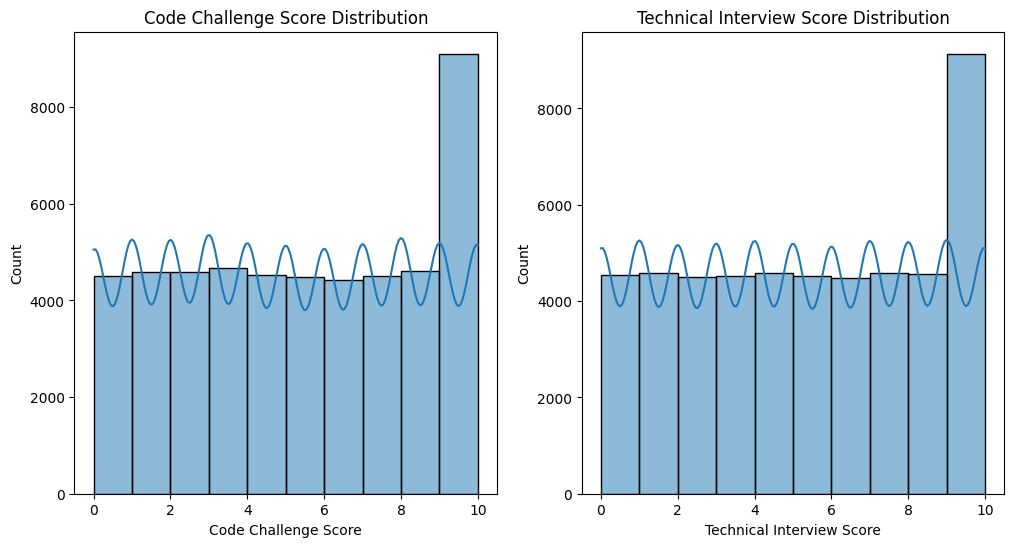

In [13]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Code Challenge Score'].dropna(), bins=10, kde=True)
plt.title('Code Challenge Score Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['Technical Interview Score'].dropna(), bins=10, kde=True)
plt.title('Technical Interview Score Distribution')
plt.show()

The charts expose a potential skew in score distributions, with a perfect score (10) being disproportionately common. While this might reflect the overall quality of applicants, it could also signal a systemic bias or evaluative bottleneck.

Understanding the root cause of this anomaly will enhance the credibility of the evaluation process and ensure more accurate differentiation of applicant capabilities.


##### Scores and Seniority boxplot
    

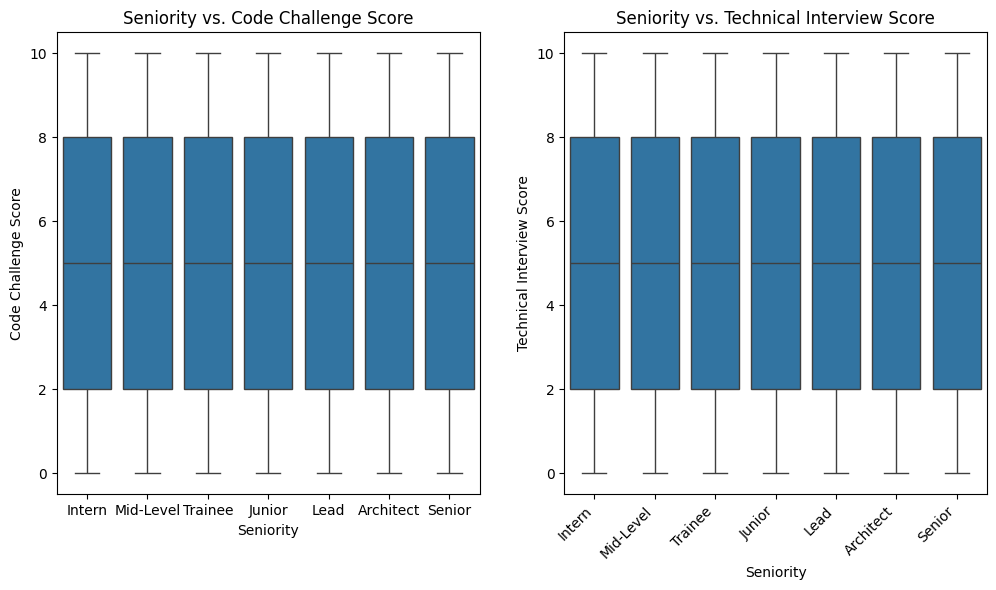

In [34]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Seniority', y='Code Challenge Score', data=df.dropna(subset=['Seniority', 'Code Challenge Score']))
plt.title('Seniority vs. Code Challenge Score')
plt.subplot(1, 2, 2)
sns.boxplot(x='Seniority', y='Technical Interview Score', data=df.dropna(subset=['Seniority', 'Technical Interview Score']))
plt.title('Seniority vs. Technical Interview Score')
plt.xticks(rotation=45, ha='right')
plt.show()

- **Neutral Scoring Across Seniority Levels:** The lack of significant differences in median scores indicates a scoring system that doesn’t heavily favor experienced professionals or is flawed. 

##### Scotres Correlations



We are going to visualize and print correlations between specified columns and scores. For this we need to converts 'Seniority' to numerical values (dummy) before calculating correlations.

Correlation Matrix: Scores
                           Code Challenge Score  Technical Interview Score
Code Challenge Score                   1.000000                  -0.002373
Technical Interview Score             -0.002373                   1.000000


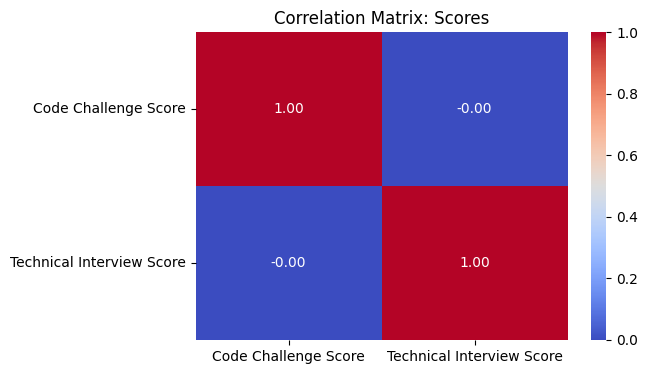


Correlation Matrix: YOE and Scores
                                YOE  Code Challenge Score  \
YOE                        1.000000              0.005871   
Code Challenge Score       0.005871              1.000000   
Technical Interview Score -0.005878             -0.002373   

                           Technical Interview Score  
YOE                                        -0.005878  
Code Challenge Score                       -0.002373  
Technical Interview Score                   1.000000  


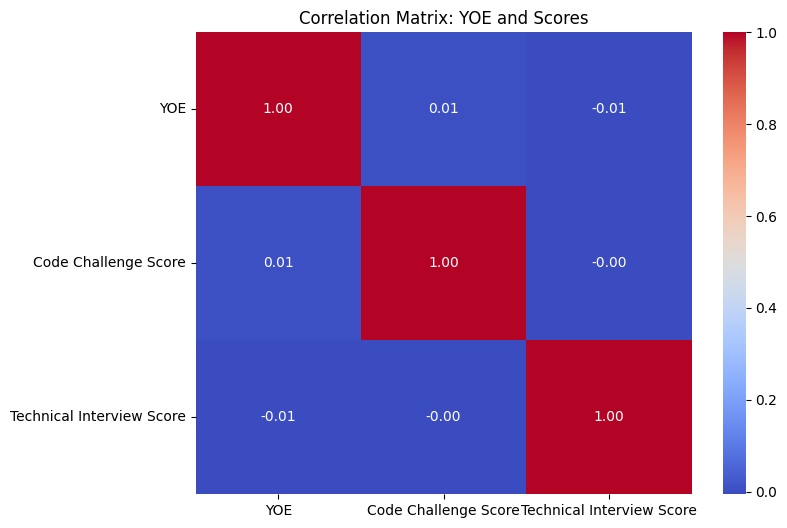

In [35]:
def calculate_correlation_matrices(df):


    # 1. Correlation Matrix: Scores
    scores_corr_matrix = df[['Code Challenge Score', 'Technical Interview Score']].corr()
    print("Correlation Matrix: Scores")
    print(scores_corr_matrix)
    plt.figure(figsize=(6, 4))
    sns.heatmap(scores_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix: Scores")
    plt.show()

    # 2. Correlation Matrix: YOE and Scores
    yoe_scores_corr_matrix = df[['YOE', 'Code Challenge Score', 'Technical Interview Score']].corr()
    print("\nCorrelation Matrix: YOE and Scores")
    print(yoe_scores_corr_matrix)
    plt.figure(figsize=(8, 6))
    sns.heatmap(yoe_scores_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix: YOE and Scores")
    plt.show()


calculate_correlation_matrices(df)

- YOE does not strongly predict success in either Code Challenges or Technical Interviews. This finding supports the idea that skill level, recent training, or familiarity with evaluation formats might be more important than raw experience.

- The lack of strong correlations suggests that each variable (YOE, Code Challenge, Technical Interview) independently contributes to a candidate's overall evaluation.